# Hotel Booking Cancellation Prediction

# Part A — Exploratory Data Analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, shapiro
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


### LOAD DATA

In [2]:
df = pd.read_csv("hotel_bookings.csv")
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head(3)


Dataset shape: 119,390 rows, 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


### TARGET VARIABLE

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


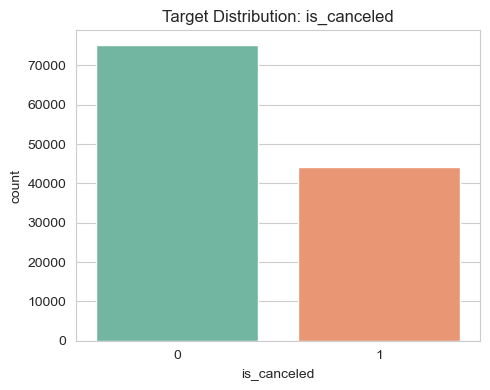

In [3]:
print(df["is_canceled"].value_counts())
print(df["is_canceled"].value_counts(normalize=True) * 100)

plt.figure(figsize=(5, 4))
sns.countplot(x="is_canceled", data=df, hue="is_canceled", palette="Set2", legend=False)
plt.title("Target Distribution: is_canceled")
plt.tight_layout()
plt.show()


### MISSING VALUES

In [4]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)
print(missing_summary)

          missing_count  missing_pct
company          112593    94.306893
agent             16340    13.686238
country             488     0.408744
children              4     0.003350


agent
False    0.390044
True     0.246634
Name: is_canceled, dtype: float64
company
False    0.175224
True     0.382200
Name: is_canceled, dtype: float64


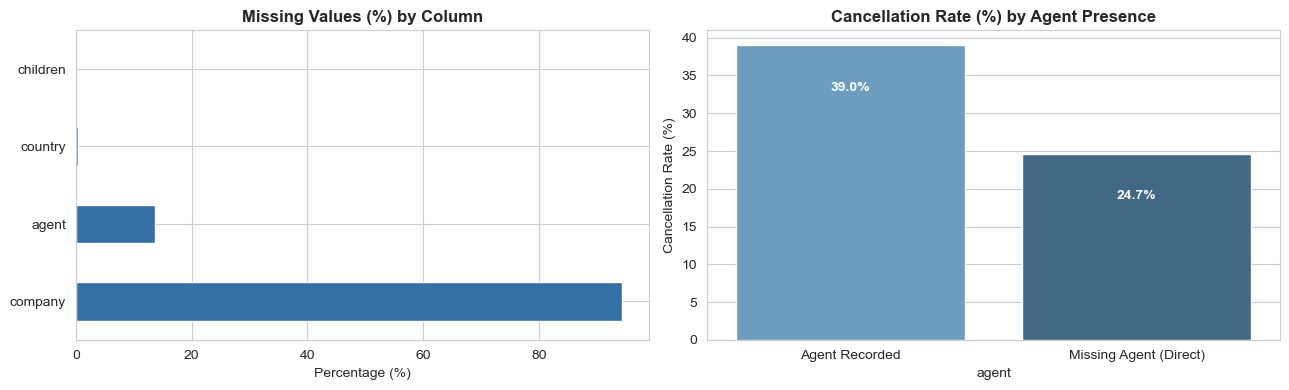

In [ ]:

print(df.groupby(df["agent"].isna())["is_canceled"].mean())
print(df.groupby(df["company"].isna())["is_canceled"].mean())


# Missingness and cancellation rate by agent presence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# 1. Missingness percentage
missing_summary.plot(kind="barh", y="missing_pct", ax=ax1, color="#3470a3", legend=False)
ax1.set_title("Missing Values (%) by Column", fontweight="bold")
ax1.set_xlabel("Percentage (%)")

# 2. Cancellation rate by Agent presence
agent_canc = df.groupby(df["agent"].isna().map({True: "Missing Agent (Direct)", False: "Agent Recorded"}))["is_canceled"].mean() * 100
sns.barplot(x=agent_canc.index, y=agent_canc.values, hue=agent_canc.index, palette="Blues_d", legend=False, ax=ax2)
ax2.set_title("Cancellation Rate (%) by Agent Presence", fontweight="bold")
ax2.set_ylabel("Cancellation Rate (%)")
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 6),
                 ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()


### HIDDEN MISSING VALUES (placeholder categories)

In [6]:
cat_cols = df.select_dtypes(exclude="number").columns
placeholder_terms = ["Undefined", "Unknown", "?", "None", "-", ""]
placeholder_rows = []
for col in cat_cols:
    for term in placeholder_terms:
        count = (df[col].astype(str).str.strip() == term).sum()
        if count > 0:
            placeholder_rows.append({"Column": col, "Placeholder": term, "Count": count,
                                      "Percentage (%)": round(count / len(df) * 100, 4)})
print(pd.DataFrame(placeholder_rows))


                 Column Placeholder  Count  Percentage (%)
0                  meal   Undefined   1169          0.9791
1        market_segment   Undefined      2          0.0017
2  distribution_channel   Undefined      5          0.0042


### DUPLICATE RECORDS

In [7]:
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates:,} ({n_duplicates / len(df) * 100:.2f}%)")

dup_group_sizes = df.value_counts(dropna=False)
dup_group_sizes = dup_group_sizes[dup_group_sizes > 1]
print(f"Duplicate groups: {len(dup_group_sizes)}, largest group: {dup_group_sizes.max()}")

dup_segments = df[df.duplicated(keep=False)]["market_segment"].value_counts(normalize=True) * 100
print(dup_segments)


Duplicate rows: 31,994 (26.80%)
Duplicate groups: 8171, largest group: 180
market_segment
Groups           41.610855
Offline TA/TO    30.399602
Online TA        20.587576
Corporate         3.669862
Direct            3.498070
Complementary     0.186730
Aviation          0.047305
Name: proportion, dtype: float64


### UNIVARIATE - NUMERIC

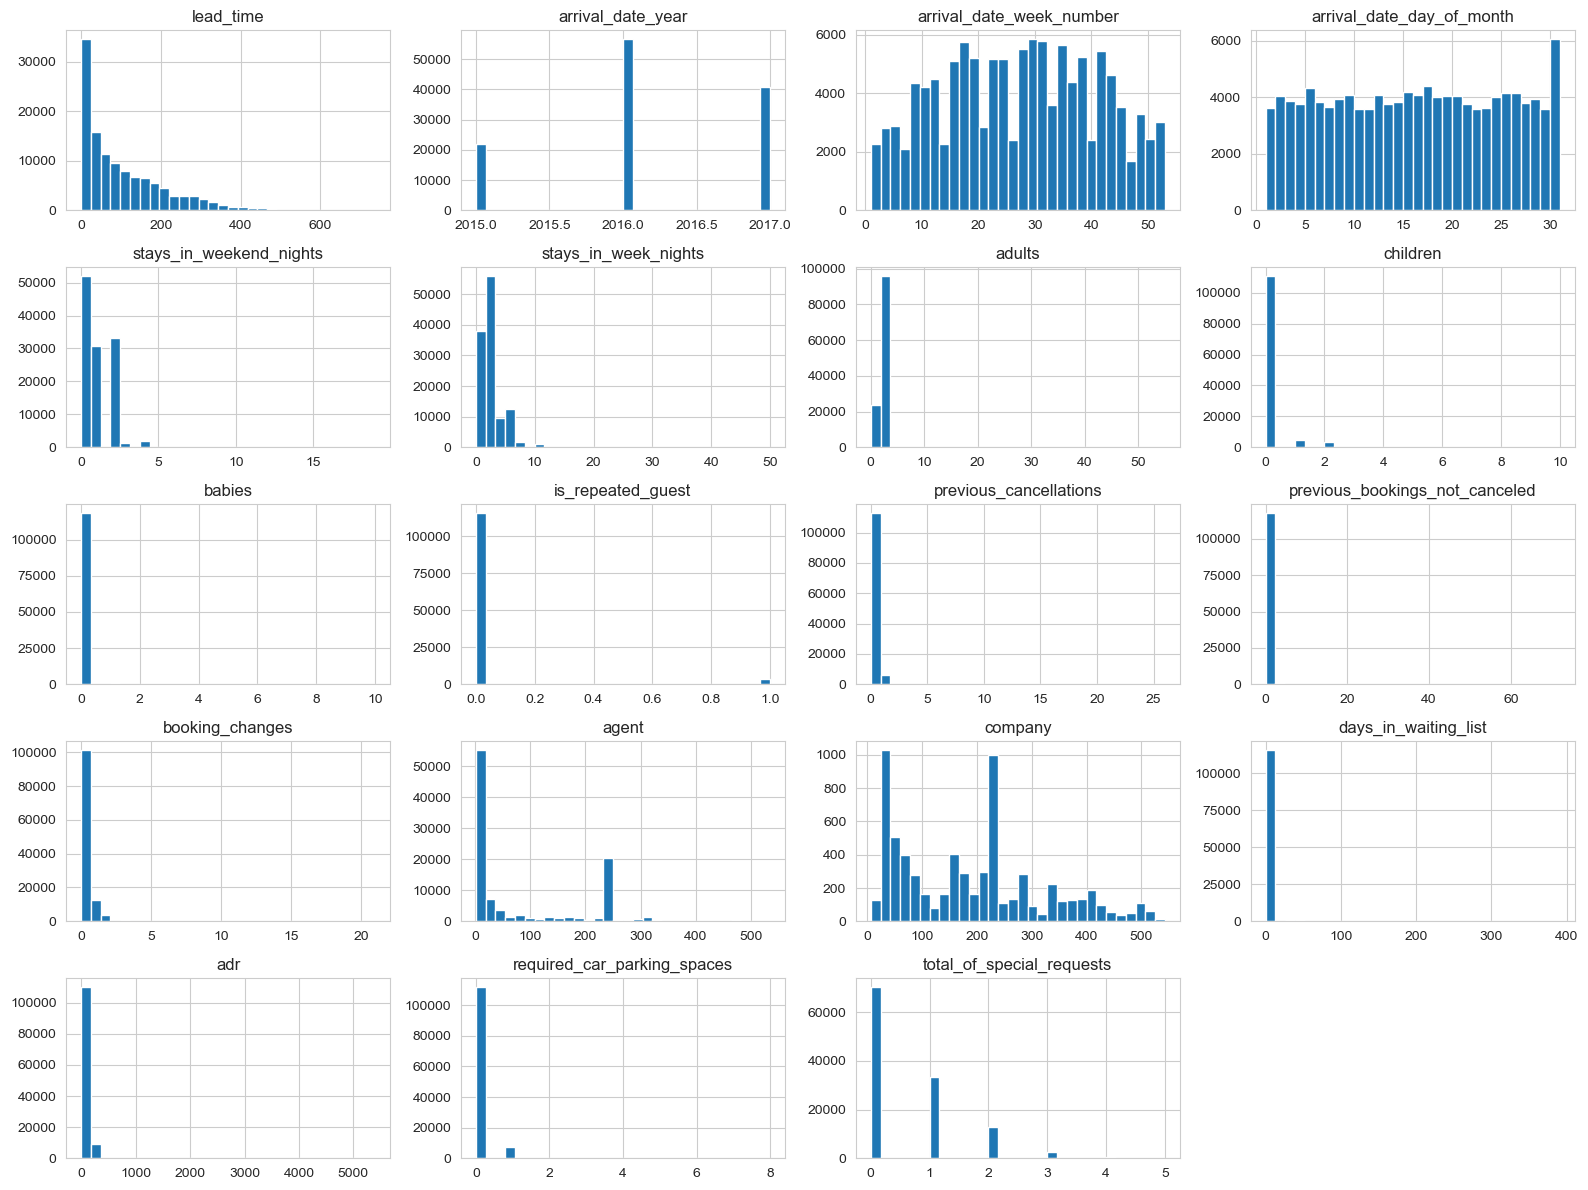

In [8]:
numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c != "is_canceled"]
df[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()


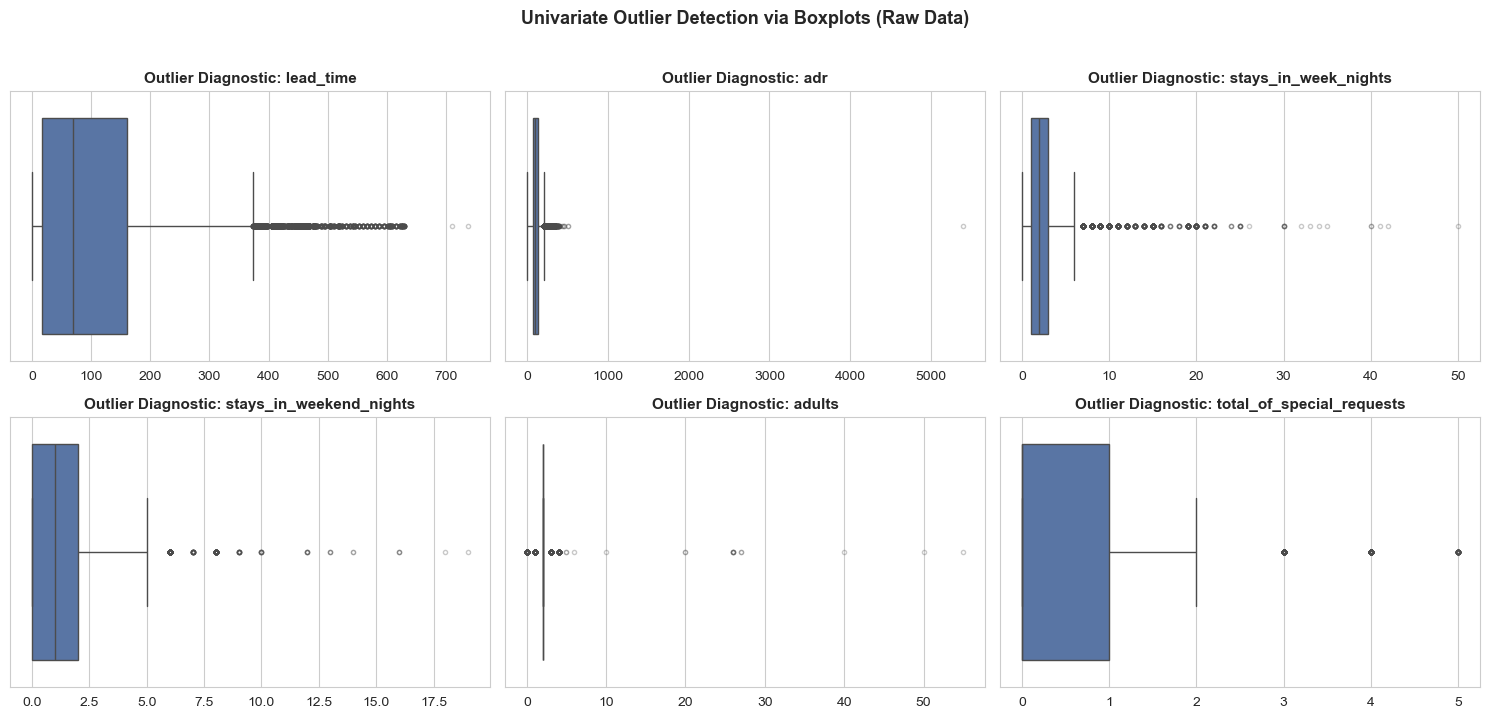

In [9]:
# Boxplots of key numeric columns (outlier check)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
key_num_cols = ["lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights", "adults", "total_of_special_requests"]

for ax, col in zip(axes.flatten(), key_num_cols):
    sns.boxplot(x=df[col], ax=ax, color="#4c72b0", flierprops=dict(marker='o', markersize=3, alpha=0.3, color='crimson'))
    ax.set_title(f"Outlier Diagnostic: {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel("")

plt.suptitle("Univariate Outlier Detection via Boxplots (Raw Data)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### SKEWNESS / NORMALITY TESTS

In [10]:
skew_rows = []
for col in numeric_cols:
    sample = df[col].dropna()
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    stat, p_value = shapiro(sample)
    skew_rows.append({"Feature": col, "Skewness": round(df[col].skew(), 3),
                       "Shapiro_p": round(p_value, 5),
                       "Normal (p>0.05)": p_value > 0.05})
skew_df = pd.DataFrame(skew_rows)
print(skew_df)


                           Feature  Skewness  Shapiro_p  Normal (p>0.05)
0                        lead_time     1.347        0.0            False
1                arrival_date_year    -0.233        0.0            False
2         arrival_date_week_number    -0.010        0.0            False
3        arrival_date_day_of_month    -0.002        0.0            False
4          stays_in_weekend_nights     1.380        0.0            False
5             stays_in_week_nights     2.862        0.0            False
6                           adults    18.318        0.0            False
7                         children     4.113        0.0            False
8                           babies    24.647        0.0            False
9                is_repeated_guest     5.326        0.0            False
10          previous_cancellations    24.458        0.0            False
11  previous_bookings_not_canceled    23.540        0.0            False
12                 booking_changes     6.000       

### CHI-SQUARE TESTS (categorical vs target)

In [11]:
cat_test_cols = ["hotel", "meal", "market_segment", "distribution_channel",
                  "reserved_room_type", "deposit_type", "customer_type"]
chi_rows = []
for col in cat_test_cols:
    table = pd.crosstab(df[col], df["is_canceled"])
    chi2, p, dof, exp = chi2_contingency(table)
    chi_rows.append({"Feature": col, "Chi2": round(chi2, 2), "p_value": p,
                      "Significant (p<0.05)": p < 0.05})
chi_df = pd.DataFrame(chi_rows)
print(chi_df)


                Feature      Chi2        p_value  Significant (p<0.05)
0                 hotel   2224.92   0.000000e+00                  True
1                  meal    304.24   1.321235e-64                  True
2        market_segment   8497.22   0.000000e+00                  True
3  distribution_channel   3745.79   0.000000e+00                  True
4    reserved_room_type    647.84  1.121956e-133                  True
5          deposit_type  27677.33   0.000000e+00                  True
6         customer_type   2222.50   0.000000e+00                  True


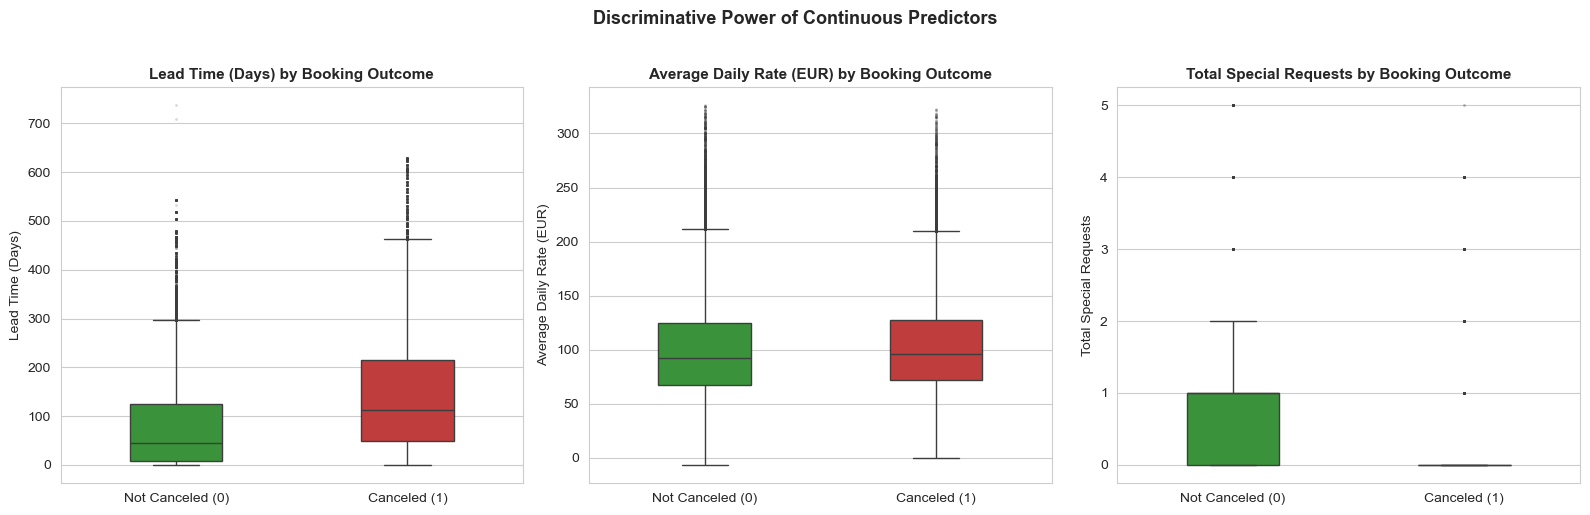

In [12]:
# Bivariate boxplots vs target
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bivariate_cols = [("lead_time", "Lead Time (Days)"), ("adr", "Average Daily Rate (EUR)"), ("total_of_special_requests", "Total Special Requests")]

for ax, (col, label) in zip(axes, bivariate_cols):
    # Filter ADR outlier for clear visualization (data-driven 99.9th percentile)
    adr_viz_cap = df["adr"].quantile(0.999)
    data_plot = df[df["adr"] < adr_viz_cap] if col == "adr" else df
    sns.boxplot(x="is_canceled", y=col, hue="is_canceled", data=data_plot, ax=ax, palette=["#2ca02c", "#d62728"], width=0.4, legend=False,
                flierprops=dict(marker='.', markersize=2, alpha=0.2))
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Not Canceled (0)", "Canceled (1)"])
    ax.set_title(f"{label} by Booking Outcome", fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(label)

plt.suptitle("Discriminative Power of Continuous Predictors", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### BIVARIATE - CANCELLATION RATE BY CATEGORY


hotel:
 hotel
City Hotel      41.726963
Resort Hotel    27.763355
Name: is_canceled, dtype: float64

market_segment:
 market_segment
Undefined        100.000000
Groups            61.062036
Online TA         36.721143
Offline TA/TO     34.316033
Aviation          21.940928
Corporate         18.734655
Direct            15.341901
Complementary     13.055182
Name: is_canceled, dtype: float64

deposit_type:
 deposit_type
Non Refund    99.362446
No Deposit    28.377022
Refundable    22.222222
Name: is_canceled, dtype: float64

customer_type:
 customer_type
Transient          40.746320
Contract           30.961727
Transient-Party    25.429868
Group              10.225303
Name: is_canceled, dtype: float64


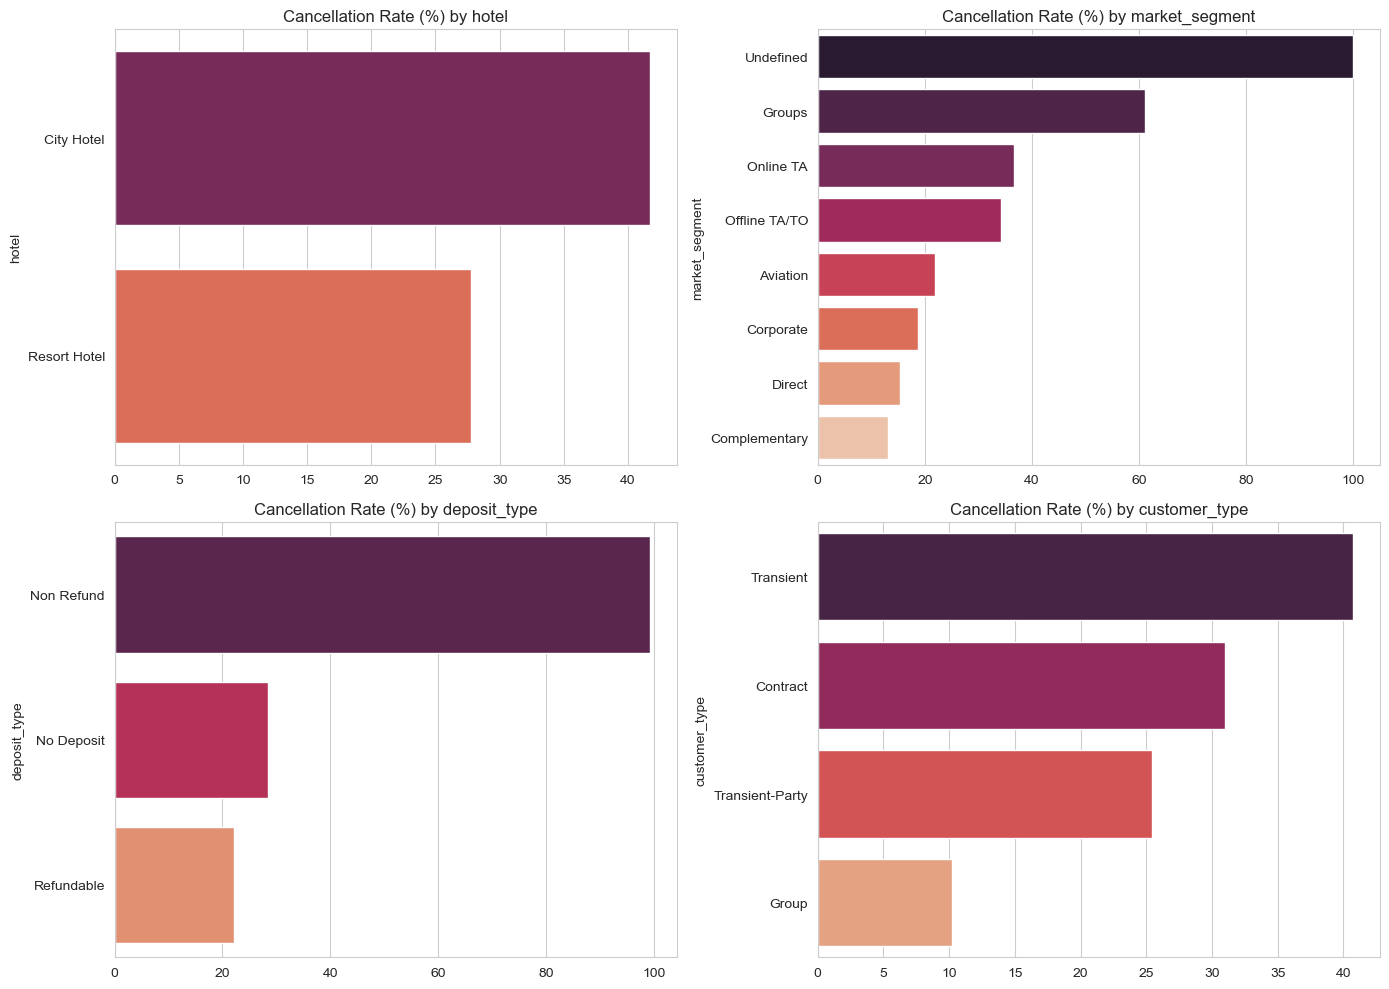

In [13]:
for col in ["hotel", "market_segment", "deposit_type", "customer_type"]:
    rate = df.groupby(col)["is_canceled"].mean().sort_values(ascending=False) * 100
    print(f"\n{col}:\n", rate)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ["hotel", "market_segment", "deposit_type", "customer_type"]):
    rate = df.groupby(col)["is_canceled"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, ax=ax, hue=rate.index, palette="rocket", legend=False)
    ax.set_title(f"Cancellation Rate (%) by {col}")
plt.tight_layout()
plt.show()


### DEPOSIT TYPE PARADOX

              Total Bookings  Total Canceled  Cancellation Rate (%)
deposit_type                                                       
No Deposit            104641           29694                  28.38
Non Refund             14587           14494                  99.36
Refundable               162              36                  22.22
market_segment
Groups           9172
Offline TA/TO    5006
Corporate         334
Online TA          56
Direct             19
Name: count, dtype: int64


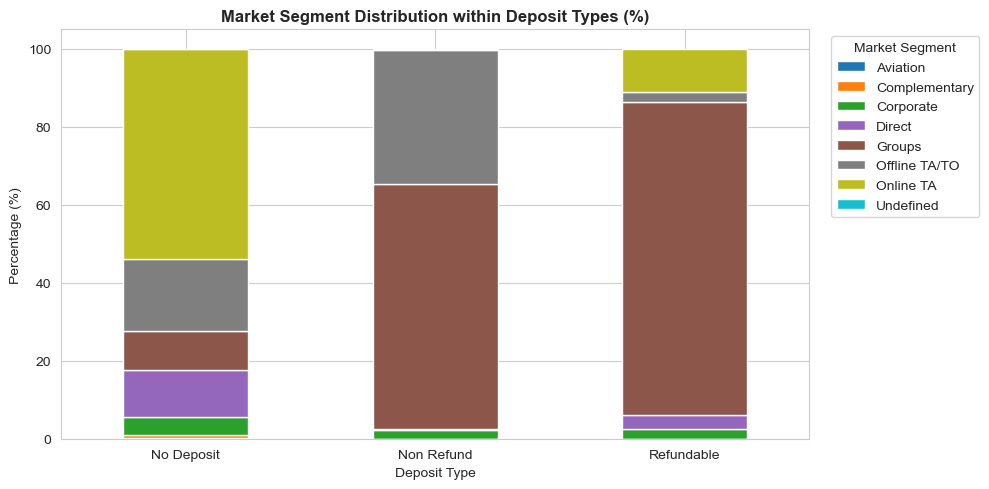

In [14]:
deposit_summary = df.groupby("deposit_type")["is_canceled"].agg(["count", "sum", "mean"])
deposit_summary["mean"] *= 100
deposit_summary.columns = ["Total Bookings", "Total Canceled", "Cancellation Rate (%)"]
print(deposit_summary.round(2))

nr_segment = df[df["deposit_type"] == "Non Refund"]["market_segment"].value_counts()
print(nr_segment)


# Market segment mix within each deposit type
ct = pd.crosstab(df["deposit_type"], df["market_segment"], normalize="index") * 100
ax = ct.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="tab10", edgecolor="white")
plt.title("Market Segment Distribution within Deposit Types (%)", fontweight="bold", fontsize=12)
plt.ylabel("Percentage (%)")
plt.xlabel("Deposit Type")
plt.xticks(rotation=0)
plt.legend(title="Market Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### CORRELATION HEATMAP

is_canceled                       1.000000
lead_time                         0.293123
previous_cancellations            0.110133
adults                            0.060017
days_in_waiting_list              0.054186
adr                               0.047557
stays_in_week_nights              0.024765
arrival_date_year                 0.016660
arrival_date_week_number          0.008148
children                          0.005048
stays_in_weekend_nights          -0.001791
arrival_date_day_of_month        -0.006130
company                          -0.020642
babies                           -0.032491
previous_bookings_not_canceled   -0.057358
agent                            -0.083114
is_repeated_guest                -0.084793
booking_changes                  -0.144381
required_car_parking_spaces      -0.195498
total_of_special_requests        -0.234658
Name: is_canceled, dtype: float64


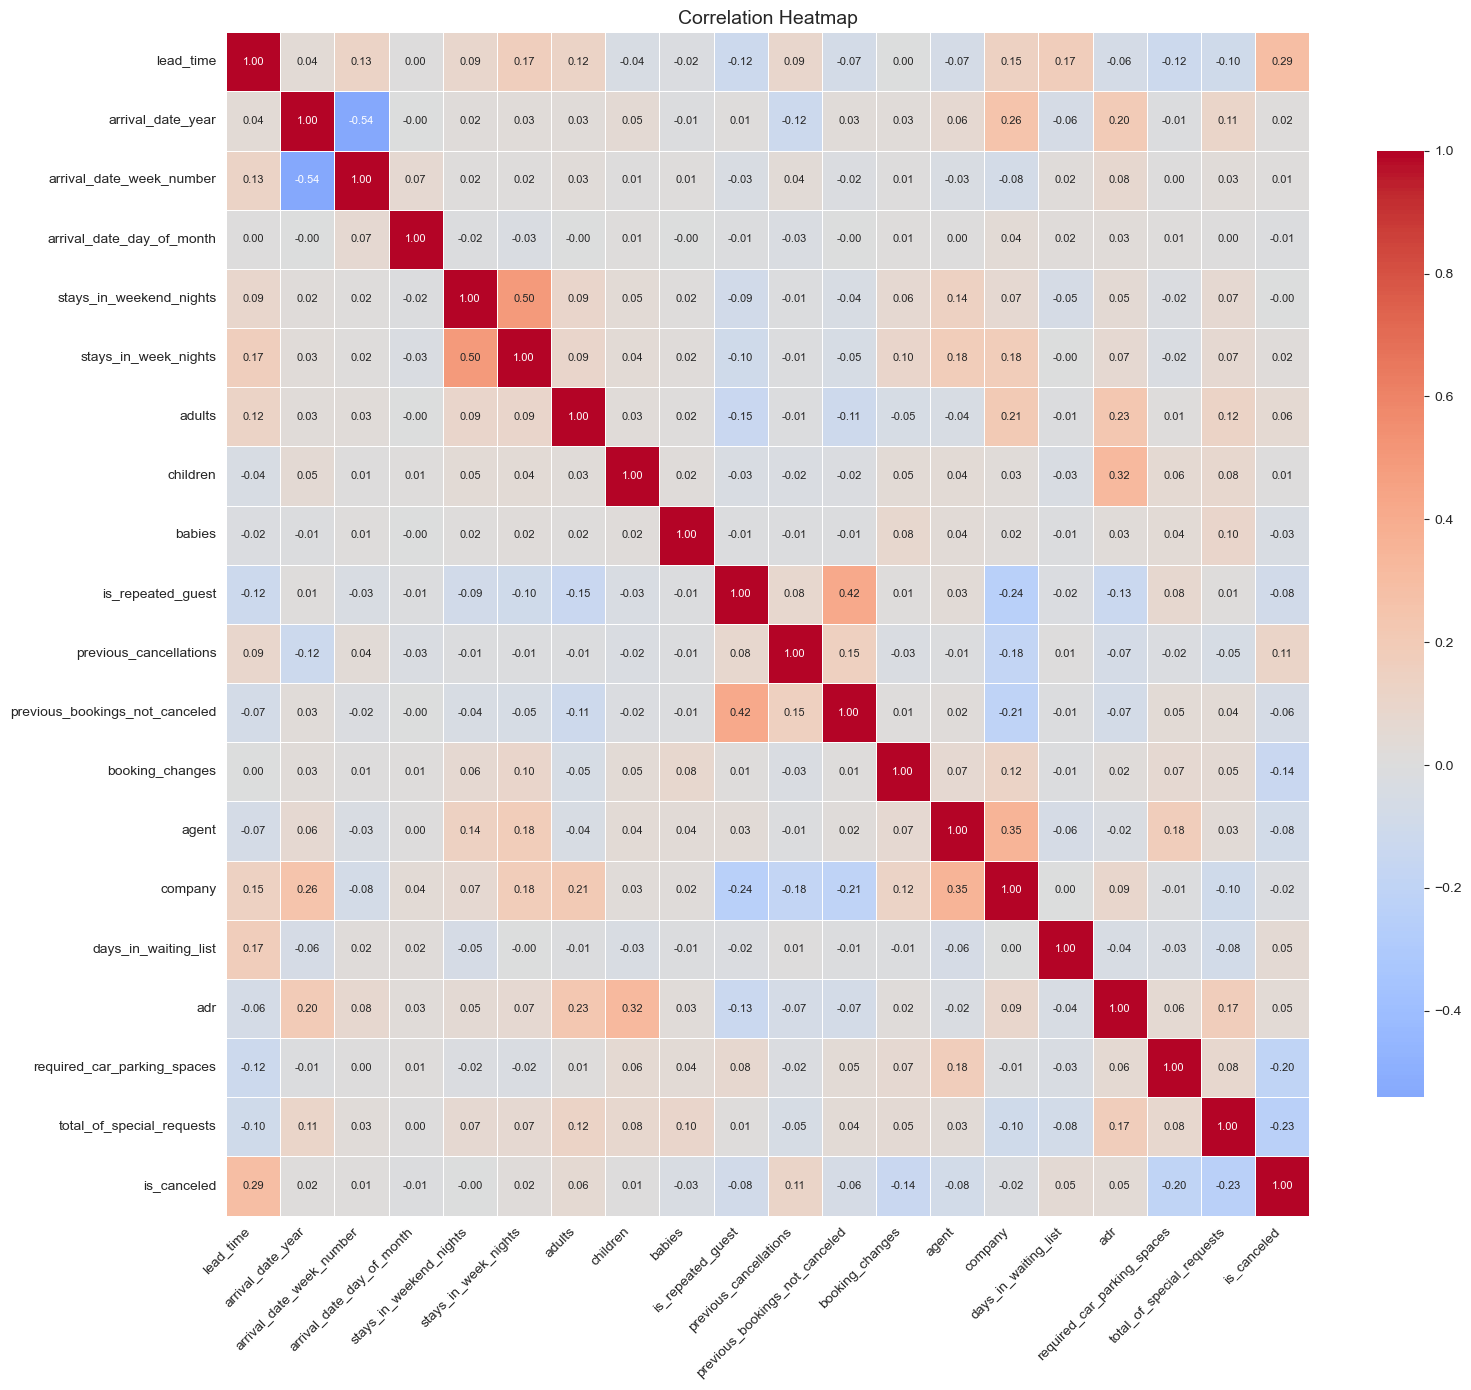

In [15]:
corr_matrix = df[numeric_cols + ["is_canceled"]].corr()
print(corr_matrix["is_canceled"].sort_values(ascending=False))

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### INVALID RECORDS

In [16]:
# Data-driven ADR upper threshold (99.9th percentile — avoids hardcoding)
adr_upper = df["adr"].quantile(0.999)
print(f"Data-driven ADR upper threshold (99.9th pct): {adr_upper:.2f} EUR")

zero_guests = ((df["adults"] + df["children"].fillna(0) + df["babies"]) == 0).sum()
zero_nights = ((df["stays_in_weekend_nights"] == 0) & (df["stays_in_week_nights"] == 0)).sum()
print("Zero guest rows:", zero_guests)
print("Zero night rows:", zero_nights)
print("Negative ADR rows:", (df["adr"] < 0).sum())
print(f"ADR > {adr_upper:.2f} rows (99.9th pct):", (df["adr"] > adr_upper).sum())


Data-driven ADR upper threshold (99.9th pct): 326.20 EUR
Zero guest rows: 180
Zero night rows: 715
Negative ADR rows: 1
ADR > 326.20 rows (99.9th pct): 120


### DATA LEAKAGE ANALYSIS

In [17]:
print(pd.crosstab(df["reservation_status"], df["is_canceled"]))

room_diff = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)
print(df.groupby(room_diff)["is_canceled"].agg(["count", "mean"]))

print(df.groupby(df["booking_changes"] > 0)["is_canceled"].agg(["count", "mean"]))
print(df.groupby(df["days_in_waiting_list"] > 0)["is_canceled"].agg(["count", "mean"]))

leakage_cols = ["reservation_status", "reservation_status_date",
                 "assigned_room_type", "booking_changes", "days_in_waiting_list"]

audit_data = []
for col in df.columns:
    if col == "is_canceled":
        cat, action = "Target Variable", "Predict"
    elif col in ["reservation_status", "reservation_status_date"]:
        cat, action = "Target Outcome Leakage", "Drop"
    elif col == "assigned_room_type":
        cat, action = "Operational Lookahead Leakage", "Drop"
    elif col == "booking_changes":
        cat, action = "Temporal Lookahead Leakage", "Drop"
    elif col == "days_in_waiting_list":
        cat, action = "Operational Queue Leakage", "Drop"
    else:
        cat, action = "Available at Booking Time", "Retain"
    audit_data.append({"Feature": col, "Category": cat, "Action": action})
audit_df = pd.DataFrame(audit_data)
print(audit_df["Category"].value_counts())
print(audit_df.to_string(index=False))

# =========================================================
# PREPROCESSING
# =========================================================


is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207
    count      mean
0  104473  0.415629
1   14917  0.053764
                  count      mean
booking_changes                  
False            101314  0.408542
True              18076  0.156727
                       count      mean
days_in_waiting_list                  
False                 115692  0.361866
True                    3698  0.637912
Category
Available at Booking Time        26
Target Outcome Leakage            2
Target Variable                   1
Operational Lookahead Leakage     1
Temporal Lookahead Leakage        1
Operational Queue Leakage         1
Name: count, dtype: int64
                       Feature                      Category  Action
                         hotel     Available at Booking Time  Retain
                   is_canceled               Target Variable Predict
                     lead

# Part B — Preprocessing & Feature Engineering

### DATA CLEANING - remove invalid records

In [ ]:
# adr_upper computed in the INVALID RECORDS diagnostic cell above
invalid_mask = (
    ((df["adults"] + df["children"].fillna(0) + df["babies"]) == 0) |
    ((df["stays_in_weekend_nights"] + df["stays_in_week_nights"]) == 0) |
    (df["adr"] < 0) |
    (df["adr"] > adr_upper)
)
print(f"Dropping {invalid_mask.sum():,} invalid records")
df_clean = df[~invalid_mask].copy()


Dropping 946 invalid records


### REMOVE EXACT DUPLICATES

In [19]:
block_booking_segments = ["Groups", "Offline TA/TO", "Corporate"]

is_block_segment = df_clean["market_segment"].isin(block_booking_segments)
# keep='first' -> one copy of each duplicated booking survives (keep=False would delete ALL copies)
is_duplicate = df_clean.duplicated(keep="first")
is_duplicate_any = df_clean.duplicated(keep=False)

# Only drop exact duplicates OUTSIDE the block-booking segments
drop_mask = is_duplicate & ~is_block_segment

print(f"Duplicates dropped (non-block segments): {drop_mask.sum():,}")
print(f"Duplicates retained (likely genuine block bookings): {(is_duplicate_any & is_block_segment).sum():,}")

df_clean = df_clean[~drop_mask].copy()
print("Shape after cleaning:", df_clean.shape)

Duplicates dropped (non-block segments): 5,683
Duplicates retained (likely genuine block bookings): 30,341
Shape after cleaning: (112761, 32)


### REMOVE LEAKAGE COLUMNS

In [20]:
df_clean = df_clean.drop(columns=leakage_cols)
print("Remaining columns:", df_clean.columns.tolist())


Remaining columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'deposit_type', 'agent', 'company', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


### POST-LEAKAGE DUPLICATE-PREDICTOR CONFLICT CHECK

In [21]:
predictor_cols = [c for c in df_clean.columns if c != "is_canceled"]
dup_predictor_rows = df_clean[df_clean.duplicated(subset=predictor_cols, keep=False)]
print("Rows with duplicate predictor combinations:", len(dup_predictor_rows))

target_counts_per_group = dup_predictor_rows.groupby(predictor_cols, dropna=False)["is_canceled"].nunique()
conflicting_groups = target_counts_per_group[target_counts_per_group > 1]
print("Duplicate predictor groups with conflicting target values:", len(conflicting_groups))
print("Decision: retain these rows; conflicting outcomes prove they are distinct bookings.")
print("Leakage across train/test will be prevented via a group-aware split.")


Rows with duplicate predictor combinations: 33254
Duplicate predictor groups with conflicting target values: 302
Decision: retain these rows; conflicting outcomes prove they are distinct bookings.
Leakage across train/test will be prevented via a group-aware split.


### HIDDEN MISSING VALUE RECODING

In [22]:
df_clean["meal"] = df_clean["meal"].replace({"Undefined": "SC"})


### FEATURE ENGINEERING (row-wise, no dataset-level statistics)

In [23]:
df_clean["has_agent"] = df_clean["agent"].notna().astype(int)
df_clean["has_company"] = df_clean["company"].notna().astype(int)

df_clean["total_nights"] = df_clean["stays_in_weekend_nights"] + df_clean["stays_in_week_nights"]
df_clean["total_guests"] = df_clean["adults"] + df_clean["children"].fillna(0) + df_clean["babies"]
df_clean["is_family"] = ((df_clean["children"].fillna(0) + df_clean["babies"]) > 0).astype(int)
df_clean["adr_per_person"] = df_clean["adr"] / np.maximum(df_clean["total_guests"], 1)
df_clean["lead_time_log"] = np.log1p(df_clean["lead_time"])

# ---- adr_log (log1p transform for scale-sensitive models) ----
df_clean["adr_log"] = np.log1p(df_clean["adr"].clip(lower=0))

# ---- lead_time_band (ordinal bucketing adds interpretability for linear models) ----
df_clean["lead_time_band"] = pd.cut(
    df_clean["lead_time"],
    bins=[-1, 7, 30, 90, 180, np.inf],
    labels=["0_same_week", "1_1_4_weeks", "2_1_3_months", "3_3_6_months", "4_6plus_months"]
).astype(str)  # string so OrdinalEncoder accepts it cleanly

# ---- prev_cancellation_rate (Laplace-smoothed; smoother than raw count) ----
total_prev = df_clean["previous_cancellations"] + df_clean["previous_bookings_not_canceled"]
df_clean["prev_cancellation_rate"] = df_clean["previous_cancellations"] / (total_prev + 1)

df_clean["has_previous_cancellation"] = (df_clean["previous_cancellations"] > 0).astype(int)
df_clean["has_parking_space"] = (df_clean["required_car_parking_spaces"] > 0).astype(int)
df_clean["has_special_requests"] = (df_clean["total_of_special_requests"] > 0).astype(int)

month_map = {"January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
             "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12}
month_num = df_clean["arrival_date_month"].map(month_map)
df_clean["arrival_month_sin"] = np.sin(2 * np.pi * month_num / 12)
df_clean["arrival_month_cos"] = np.cos(2 * np.pi * month_num / 12)
df_clean["arrival_season"] = month_num.map({12: "Winter", 1: "Winter", 2: "Winter",
                                             3: "Spring", 4: "Spring", 5: "Spring",
                                             6: "Summer", 7: "Summer", 8: "Summer",
                                             9: "Autumn", 10: "Autumn", 11: "Autumn"})

print("Columns after feature engineering:", df_clean.shape[1])


Columns after feature engineering: 43


### SEPARATE PREDICTORS AND TARGET

In [24]:
X = df_clean.drop(columns=["is_canceled"]).copy()
y = df_clean["is_canceled"].astype(int).copy()
print("X shape:", X.shape, "y shape:", y.shape)


X shape: (112761, 42) y shape: (112761,)


### GROUP-AWARE, STRATIFIED TRAIN-TEST SPLIT

In [25]:
predictor_groups = pd.util.hash_pandas_object(X, index=False)

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=predictor_groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

train_groups = set(predictor_groups.iloc[train_idx])
test_groups = set(predictor_groups.iloc[test_idx])
overlap = len(train_groups.intersection(test_groups))

print(f"X_train: {X_train.shape[0]:,} rows ({len(train_idx)/len(X)*100:.2f}%) | cancellation rate: {y_train.mean():.4f}")
print(f"X_test:  {X_test.shape[0]:,} rows ({len(test_idx)/len(X)*100:.2f}%) | cancellation rate: {y_test.mean():.4f}")
print(f"Group overlap between train and test: {overlap}")


X_train: 90,336 rows (80.11%) | cancellation rate: 0.3663
X_test:  22,425 rows (19.89%) | cancellation rate: 0.3722
Group overlap between train and test: 0


### MISSING VALUE IMPUTATION

In [26]:
med_children = X_train["children"].median()
mode_market = X_train["market_segment"].mode()[0]
mode_channel = X_train["distribution_channel"].mode()[0]

def impute_missing(data):
    out = data.copy()
    out["children"] = out["children"].fillna(med_children)
    out["country"] = out["country"].fillna("Unknown")
    out["agent"] = out["agent"].fillna(0)
    out["company"] = out["company"].fillna(0)
    out["market_segment"] = out["market_segment"].replace({"Undefined": mode_market})
    out["distribution_channel"] = out["distribution_channel"].replace({"Undefined": mode_channel})
    return out

X_train = impute_missing(X_train)
X_test = impute_missing(X_test)
print("Remaining NaNs - train:", X_train.isna().sum().sum(), "test:", X_test.isna().sum().sum())


Remaining NaNs - train: 0 test: 0


### GROUP HIGH-CARDINALITY CATEGORIES (train-only)

In [27]:
top_countries = X_train["country"].value_counts().head(15).index.tolist()
top_agents = X_train[X_train["agent"] != 0]["agent"].value_counts().head(10).index.tolist()

def group_categories(data):
    out = data.copy()
    out["country_grouped"] = out["country"].apply(lambda x: x if x in top_countries else "Other")

    def map_agent(val):
        if val == 0:
            return "Direct"
        elif val in top_agents:
            return f"Agent_{int(val)}"
        return "Other_Agent"

    out["agent_grouped"] = out["agent"].apply(map_agent)
    drop_cols = ["country", "agent", "company", "arrival_date_month",
                 "arrival_date_year", "arrival_date_day_of_month"]
    return out.drop(columns=[c for c in drop_cols if c in out.columns])

X_train = group_categories(X_train)
X_test = group_categories(X_test)

cat_cols_final = ["hotel", "meal", "market_segment", "distribution_channel", "reserved_room_type",
                   "deposit_type", "customer_type", "country_grouped", "agent_grouped", "arrival_season"]
ordinal_cols_final = ["lead_time_band"]  # encoded with explicit order, not OHE
num_cols_final = [c for c in X_train.columns if c not in cat_cols_final and c not in ordinal_cols_final]


### ENCODING (fit on train only)

In [28]:
from sklearn.preprocessing import OrdinalEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe.fit(X_train[cat_cols_final])
encoded_cols = ohe.get_feature_names_out(cat_cols_final).tolist()

X_train_ohe = pd.DataFrame(ohe.transform(X_train[cat_cols_final]), columns=encoded_cols, index=X_train.index)
X_test_ohe = pd.DataFrame(ohe.transform(X_test[cat_cols_final]), columns=encoded_cols, index=X_test.index)

# ---- OrdinalEncoder for lead_time_band (preserves meaningful order) ----
BAND_ORDER = [["0_same_week", "1_1_4_weeks", "2_1_3_months", "3_3_6_months", "4_6plus_months"]]
ord_enc = OrdinalEncoder(categories=BAND_ORDER, handle_unknown="use_encoded_value", unknown_value=-1)
ord_enc.fit(X_train[ordinal_cols_final])

X_train_ord = pd.DataFrame(
    ord_enc.transform(X_train[ordinal_cols_final]),
    columns=ordinal_cols_final, index=X_train.index
)
X_test_ord = pd.DataFrame(
    ord_enc.transform(X_test[ordinal_cols_final]),
    columns=ordinal_cols_final, index=X_test.index
)

# Assemble tree-model feature matrix (numeric + ordinal-encoded + one-hot encoded)
X_train_tree = pd.concat([X_train[num_cols_final], X_train_ord, X_train_ohe], axis=1)
X_test_tree = pd.concat([X_test[num_cols_final], X_test_ord, X_test_ohe], axis=1)
print("Tree-model feature matrix (with lead_time_band):", X_train_tree.shape)


Tree-model feature matrix (with lead_time_band): (90336, 93)


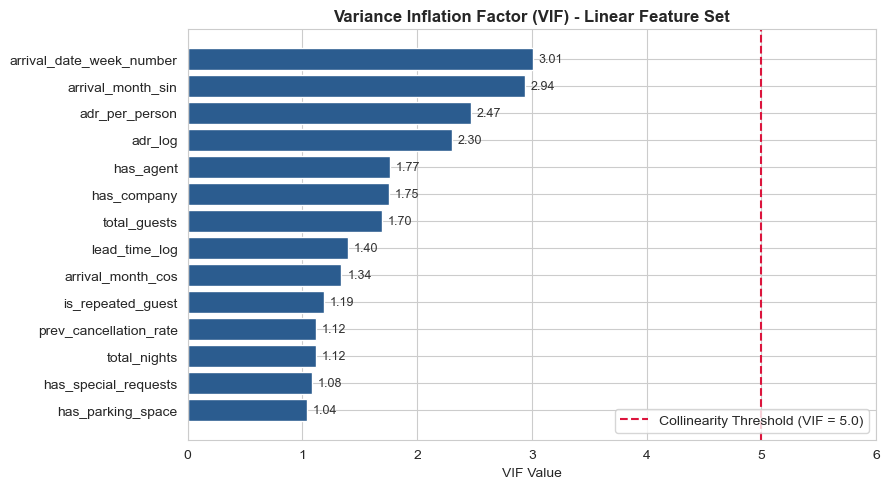

All features have VIF < 5 (max = 3.01), so there is no severe multicollinearity.


In [29]:
# VIF check on the non-redundant predictor subset used for linear/logistic modelling
linear_features = [
    'lead_time_log',
    'adr_log',
    'prev_cancellation_rate',
    'arrival_date_week_number',
    'total_nights',
    'total_guests',
    'is_repeated_guest',
    'adr_per_person',
    'has_parking_space',
    'has_special_requests',
    'has_agent',
    'has_company',
    'arrival_month_sin',
    'arrival_month_cos'
]

def compute_vif(frame):
    """VIF_j = 1 / (1 - R^2_j), where R^2_j comes from regressing feature j on all other features."""
    vifs = {}
    for col in frame.columns:
        others = frame.drop(columns=col)
        r2 = LinearRegression().fit(others, frame[col]).score(others, frame[col])
        vifs[col] = np.inf if r2 >= 1 - 1e-12 else 1.0 / (1.0 - r2)
    return pd.Series(vifs)

# lead_time_band is ordinal-encoded separately (not part of this numeric VIF check)
sample_X = X_train[linear_features].sample(min(5000, len(X_train)), random_state=42)
vif_df = (compute_vif(sample_X).rename("VIF").rename_axis("Feature").reset_index()
          .sort_values("VIF", ascending=True))

plt.figure(figsize=(9, 5))
bars = plt.barh(vif_df['Feature'], vif_df['VIF'], color='#2b5c8f')
plt.axvline(x=5.0, color='crimson', linestyle='--', linewidth=1.5, label='Collinearity Threshold (VIF = 5.0)')
plt.title("Variance Inflation Factor (VIF) - Linear Feature Set", fontsize=12, fontweight='bold')
plt.xlabel("VIF Value")
plt.legend(loc='lower right')
for bar in bars:
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.2f}",
             va='center', fontsize=9, color='#333333')
plt.xlim(0, max(6, vif_df['VIF'].max() * 1.15))
plt.tight_layout()
plt.show()

high_vif = vif_df[vif_df['VIF'] >= 5.0]
if high_vif.empty:
    print(f"All features have VIF < 5 (max = {vif_df['VIF'].max():.2f}), so there is no severe multicollinearity.")
else:
    print("Features at or above the VIF = 5 threshold (review before fitting a linear model):")
    print(high_vif.to_string(index=False))


### SCALING (winsorize + standardize, fit on train only, for linear/distance models)

In [30]:
p99_adr = X_train["adr"].quantile(0.99)

def winsorize(data):
    out = data.copy()
    out["adults"] = np.clip(out["adults"], 1, 4)
    out["children"] = np.clip(out["children"], 0, 3)
    out["babies"] = np.clip(out["babies"], 0, 2)
    out["adr"] = np.clip(out["adr"], 0, p99_adr)
    out["adr_per_person"] = np.clip(out["adr_per_person"], 0, p99_adr)
    # Recompute adr_log after winsorization so the transform reflects the clipped value
    out["adr_log"] = np.log1p(out["adr"].clip(lower=0))
    return out

# Ensure num_cols_final strictly contains numeric columns only
num_cols_final = [c for c in X_train.columns if c not in cat_cols_final and c not in ordinal_cols_final]

X_train_winsor = winsorize(X_train[num_cols_final])
X_test_winsor = winsorize(X_test[num_cols_final])

scaler = StandardScaler()
X_train_scaled_num = pd.DataFrame(scaler.fit_transform(X_train_winsor), columns=num_cols_final, index=X_train.index)
X_test_scaled_num = pd.DataFrame(scaler.transform(X_test_winsor), columns=num_cols_final, index=X_test.index)

X_train_scaled = pd.concat([X_train_scaled_num, X_train_ord, X_train_ohe], axis=1)
X_test_scaled = pd.concat([X_test_scaled_num, X_test_ord, X_test_ohe], axis=1)
print("Scaled feature matrix:", X_train_scaled.shape)


Scaled feature matrix: (90336, 93)


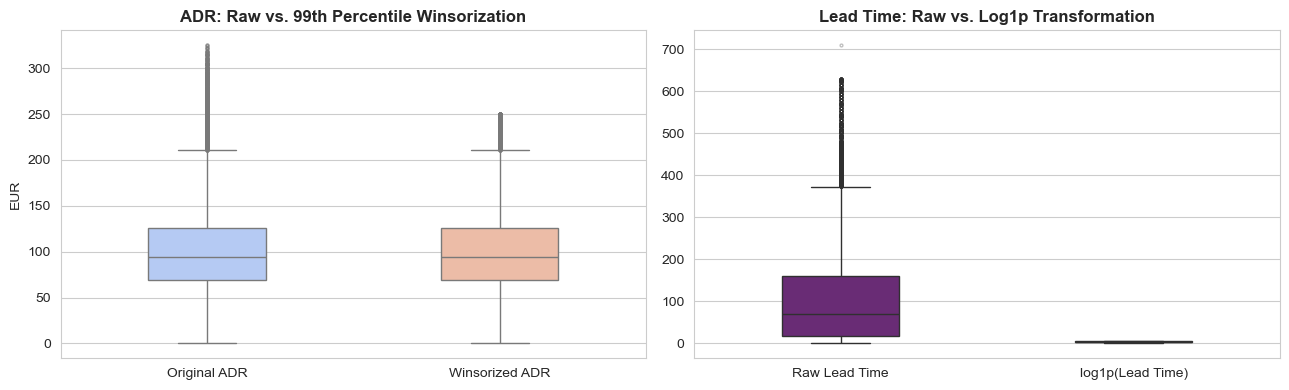

In [31]:
# Effect of winsorization and log transform
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 1. ADR Winsorization comparison
adr_comp = pd.DataFrame({"Original ADR": X_train["adr"], "Winsorized ADR": X_train_winsor["adr"]})
sns.boxplot(data=adr_comp, ax=axes[0], palette="coolwarm", width=0.4, flierprops=dict(markersize=2, alpha=0.3))
axes[0].set_title("ADR: Raw vs. 99th Percentile Winsorization", fontweight="bold")
axes[0].set_ylabel("EUR")

# 2. Lead Time Log1p Transformation
lead_comp = pd.DataFrame({"Raw Lead Time": df_clean["lead_time"], "log1p(Lead Time)": df_clean["lead_time_log"]})
sns.boxplot(data=lead_comp, ax=axes[1], palette="magma", width=0.4, flierprops=dict(markersize=2, alpha=0.3))
axes[1].set_title("Lead Time: Raw vs. Log1p Transformation", fontweight="bold")

plt.tight_layout()
plt.show()


### FEATURE IMPORTANCE CHECK

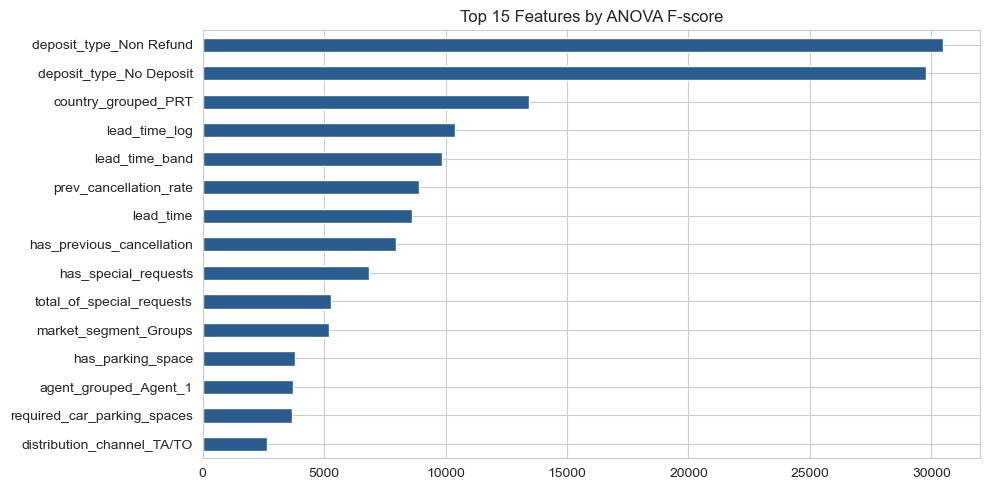

deposit_type_Non Refund      30475.861305
deposit_type_No Deposit      29786.426950
country_grouped_PRT          13447.020627
lead_time_log                10393.590114
lead_time_band                9839.367300
prev_cancellation_rate        8898.103327
lead_time                     8638.477265
has_previous_cancellation     7977.587753
has_special_requests          6868.417268
total_of_special_requests     5304.787879
dtype: float64


In [32]:
from sklearn.feature_selection import f_classif

f_scores, p_values = f_classif(X_train_tree, y_train)
feature_scores = pd.Series(f_scores, index=X_train_tree.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feature_scores.head(15).sort_values().plot(kind="barh", color="#2b5c8f")
plt.title("Top 15 Features by ANOVA F-score")
plt.tight_layout()
plt.show()

print(feature_scores.head(10))


### SAVE OUTPUTS

In [33]:
os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

X_train_tree.to_csv("data/X_train_tree.csv", index=False)
X_test_tree.to_csv("data/X_test_tree.csv", index=False)
X_train_scaled.to_csv("data/X_train_scaled.csv", index=False)
X_test_scaled.to_csv("data/X_test_scaled.csv", index=False)
y_train.to_csv("data/y_train.csv", index=False)
y_test.to_csv("data/y_test.csv", index=False)

# Metadata for the model notebooks (KNN_Model.ipynb, Random_Forest_Model.ipynb):
# CV group ids (same hashing as the train/test split), arrival date (time-based check)
# and country group (fairness check). Rows are aligned with the X/y files above.
arrival_date = pd.to_datetime(df_clean["arrival_date_year"].astype(str) + "-" +
                              df_clean["arrival_date_month"] + "-01", format="%Y-%B-%d")
for name, X_part, pos in [("train", X_train, train_idx), ("test", X_test, test_idx)]:
    pd.DataFrame({
        "group": predictor_groups.iloc[pos].to_numpy(),
        "arrival_date": arrival_date.loc[X_part.index].to_numpy(),
        "country_grouped": X_part["country_grouped"].to_numpy(),
    }).to_csv(f"data/meta_{name}.csv", index=False)

# Fitted preprocessing objects (needed to transform new bookings at prediction time)
import joblib
joblib.dump({"scaler": scaler, "ohe": ohe, "ord_enc": ord_enc,
             "cat_cols": cat_cols_final, "ordinal_cols": ordinal_cols_final, "num_cols": num_cols_final,
             "top_countries": top_countries, "top_agents": top_agents, "p99_adr": p99_adr,
             "med_children": med_children, "mode_market": mode_market, "mode_channel": mode_channel},
            "models/preprocessors.joblib")

print("Preprocessing complete.")


Preprocessing complete.


### CLASS IMBALANCE - SMOTE-RESAMPLED TRAINING SET (training data only)

The original, untouched files saved above are kept. This cell adds a **separate** balanced copy of the *scaled training set only*.

- `X_test_scaled.csv` / `y_test.csv` are never resampled; always evaluate on them (real-world class balance).
- Safe to use for fitting final models or a simple hold-out. For **cross-validation / hyper-parameter tuning**, do not use this file as the CV input (synthetic rows built from validation-fold neighbours would leak); resample inside each training fold instead.
- Tree models can use the original files with `class_weight` / `scale_pos_weight`.


In [34]:
def smote_nc(X, y, categorical_mask, k=5, random_state=42):

    rng = np.random.default_rng(random_state)
    counts = y.value_counts()
    minority_label = counts.idxmin()
    n_new = int(counts.max() - counts.min())

    cat_mask = np.asarray(categorical_mask, dtype=bool)
    num_idx, cat_idx = np.where(~cat_mask)[0], np.where(cat_mask)[0]
    X_min = X.loc[y == minority_label].to_numpy(dtype=float)

    penalty = np.median(X_min[:, num_idx].std(axis=0)) / np.sqrt(2)
    X_dist = np.hstack([X_min[:, num_idx], X_min[:, cat_idx] * penalty])
    neigh_full = NearestNeighbors(n_neighbors=k + 1).fit(X_dist).kneighbors(X_dist, return_distance=False)
    neigh = np.array([row[row != i][:k] for i, row in enumerate(neigh_full)])  # drop the row itself

    base = rng.integers(0, len(X_min), n_new)
    nbr = neigh[base, rng.integers(0, k, n_new)]
    gap = rng.random((n_new, 1))

    synth = X_min[base].copy()
    synth[:, num_idx] = X_min[base][:, num_idx] + gap * (X_min[nbr][:, num_idx] - X_min[base][:, num_idx])

    X_new = pd.DataFrame(synth, columns=X.columns)
    y_new = pd.Series(minority_label, index=X_new.index, name=y.name)
    X_out = pd.concat([X.reset_index(drop=True), X_new], ignore_index=True)
    y_out = pd.concat([y.reset_index(drop=True), y_new], ignore_index=True)
    order = rng.permutation(len(X_out))
    return X_out.iloc[order].reset_index(drop=True), y_out.iloc[order].reset_index(drop=True)


assert list(X_train_tree.columns) == list(X_train_scaled.columns)
binary_cols = X_train_tree.columns[X_train_tree.nunique() <= 2]
categorical_mask = X_train_scaled.columns.isin(binary_cols) | (X_train_scaled.columns == "lead_time_band")

print("Before SMOTE:")
print(y_train.value_counts().to_string())

X_train_scaled_smote, y_train_smote = smote_nc(X_train_scaled, y_train, categorical_mask, k=5, random_state=42)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts().to_string())
print(f"\nOriginal training rows: {len(X_train_scaled):,} | SMOTE-resampled training rows: {len(X_train_scaled_smote):,}")

# sanity checks: no NaNs, one-hot groups still valid, test set untouched
assert not X_train_scaled_smote.isna().any().any()
for prefix in ["hotel_", "meal_", "market_segment_", "agent_grouped_", "country_grouped_"]:
    group_cols = [c for c in X_train_scaled_smote.columns if c.startswith(prefix)]
    assert (X_train_scaled_smote[group_cols].sum(axis=1).round(6) == 1).all(), prefix
print("Sanity checks passed. Test set shape (unchanged):", X_test_scaled.shape)

X_train_scaled_smote.to_csv("data/X_train_scaled_smote.csv", index=False)
y_train_smote.to_csv("data/y_train_smote.csv", index=False)


Before SMOTE:
is_canceled
0    57243
1    33093



After SMOTE:
is_canceled
0    57243
1    57243

Original training rows: 90,336 | SMOTE-resampled training rows: 114,486
Sanity checks passed. Test set shape (unchanged): (22425, 93)
